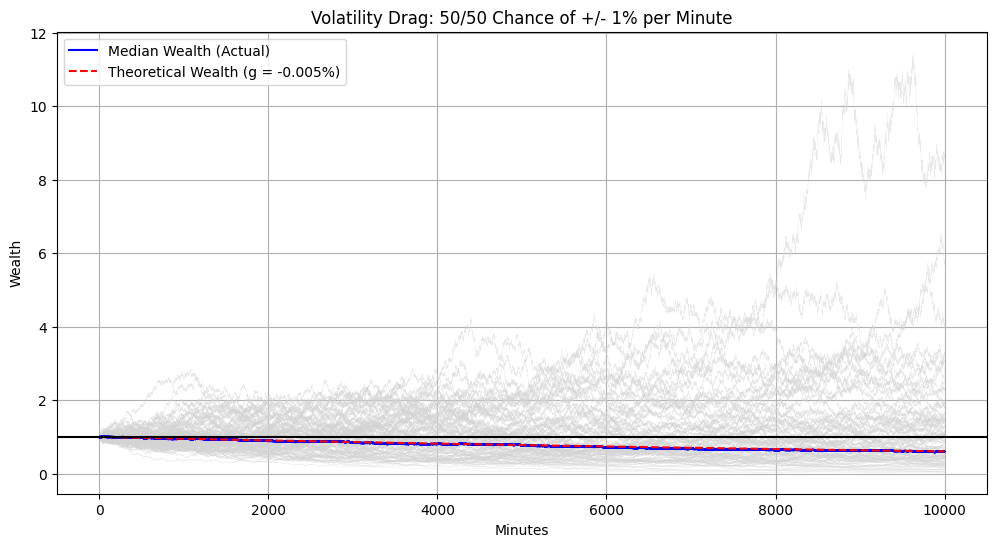

经过 10000 分钟后:
账户净值中位数: 0.6065
理论计算净值: 0.6066
平均每分钟损失: 0.00500%


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 参数设置
n_steps = 10000     # 模拟次数（分钟）
n_paths = 1000      # 模拟的独立路径数量
up_down = 0.01      # 涨跌幅 1%

# 模拟收益率：1.01 或 0.99
# 生成一个 (n_steps, n_paths) 的矩阵，元素为 1.01 或 0.99
returns = np.random.choice([1 + up_down, 1 - up_down], size=(n_steps, n_paths))

# 计算累计财富：初始资金为 1，进行连乘
wealth_paths = np.cumprod(returns, axis=0)

# 计算理论预期值
# 1. 算术平均增长率 m = 0
# 2. 方差 s^2 = 0.01^2 = 0.0001
# 3. 理论复合增长率 g = m - s^2 / 2 = -0.00005 (即每分钟损失 0.5 bp)
expected_g = -0.5 * (up_down**2)
theoretical_wealth = np.exp(expected_g * np.arange(n_steps))

# 绘图
plt.figure(figsize=(12, 6))
plt.plot(wealth_paths[:, :100], color='lightgray', linewidth=0.3, alpha=0.5) # 画前50条路径
plt.plot(np.median(wealth_paths, axis=1), color='blue', label='Median Wealth (Actual)')
plt.plot(theoretical_wealth, color='red', linestyle='--', label='Theoretical Wealth (g = -0.005%)')
plt.axhline(y=1, color='black', linestyle='-')
plt.title(f"Volatility Drag: 50/50 Chance of +/- 1% per Minute")
plt.xlabel("Minutes")
plt.ylabel("Wealth")
plt.legend()
plt.grid(True)
plt.show()

# 输出最终统计结果
final_median = np.median(wealth_paths[-1, :])
print(f"经过 {n_steps} 分钟后:")
print(f"账户净值中位数: {final_median:.4f}")
print(f"理论计算净值: {theoretical_wealth[-1]:.4f}")
print(f"平均每分钟损失: {(1 - final_median**(1/n_steps))*100:.5f}%")

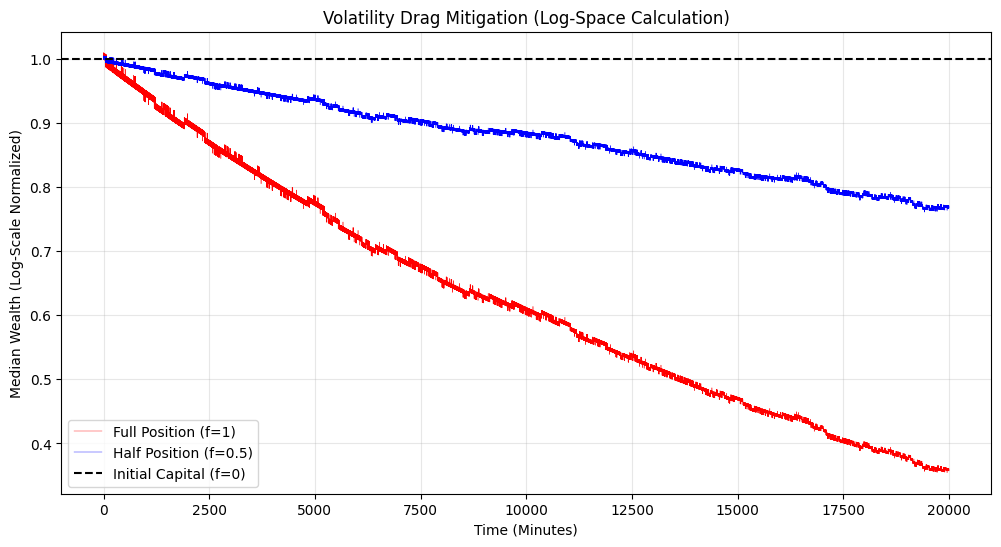

全仓 (f=1) 最终中位数净值: 0.3606
半仓 (f=0.5) 最终中位数净值: 0.7710


In [10]:
# 1. 生成原始收益率 R (0.01 或 -0.01)
raw_returns = np.random.choice([up_down, -up_down], size=(n_steps, n_paths))

# 2. 在对数空间计算财富路径，避免 np.cumprod 导致的溢出
# 全仓 f=1: log_wealth = sum(log(1 + 1.0 * R))
log_returns_f1 = np.log(1 + 1.0 * raw_returns)
log_wealth_f1 = np.cumsum(log_returns_f1, axis=0)

# 半仓 f=0.5: log_wealth = sum(log(1 + 0.5 * R))
log_returns_f05 = np.log(1 + 0.5 * raw_returns)
log_wealth_f05 = np.cumsum(log_returns_f05, axis=0)

# 3. 计算中位数（在中位数空间计算再转指数，比直接转指数更安全）
median_log_f1 = np.median(log_wealth_f1, axis=1)
median_log_f05 = np.median(log_wealth_f05, axis=1)

# 4. 绘图
plt.figure(figsize=(12, 6))
plt.plot(np.exp(median_log_f1), label='Full Position (f=1)', color='red', linewidth=0.3)
plt.plot(np.exp(median_log_f05), label='Half Position (f=0.5)', color='blue', linewidth=0.3)
plt.axhline(y=1, color='black', linestyle='--', label='Initial Capital (f=0)')

plt.title("Volatility Drag Mitigation (Log-Space Calculation)")
plt.xlabel("Time (Minutes)")
plt.ylabel("Median Wealth (Log-Scale Normalized)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 输出结果
print(f"全仓 (f=1) 最终中位数净值: {np.exp(median_log_f1[-1]):.4f}")
print(f"半仓 (f=0.5) 最终中位数净值: {np.exp(median_log_f05[-1]):.4f}")